# Week 6: Deep and Modern Convolutional Neural Networks

**Lecture 11:** Deep CNNs  
**Lecture 12:** Modern CNNs, modules and residual connections (Inception and ResNet)

This notebook moves from a shallow CNN to deeper, reusable architectures. We implement VGG-style stacks, Inception modules, and residual networks directly in PyTorch, then train one selected architecture on Imagenette2. Interpretability methods are intentionally reserved for Lecture 13.

## Setup

The organization is the same as Week 5. Because this notebook runs from its own folder, Imagenette2 is referenced directly at `../../datasets/imagenette2`, checkpoints are written to `checkpoints`, and CUDA is selected automatically. Restart the VS Code kernel after changing environments.

In [1]:
from copy import deepcopy
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is unavailable; full training will be slow.")

PyTorch version: 2.11.0+cu128
device: cuda
GPU: NVIDIA GeForce RTX 3090


In [2]:
DATA_ROOT = Path("../../datasets/imagenette2")
CHECKPOINT_DIRECTORY = Path("checkpoints")
CHECKPOINT_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODEL_TO_TRAIN = "resnet18"
IMAGE_SIZE = 299 if MODEL_TO_TRAIN == "inception_v3" else 128
BATCH_SIZE = 32 if MODEL_TO_TRAIN == "inception_v3" else 128
MAXIMUM_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 8
MINIMUM_IMPROVEMENT = 1e-4

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
training_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
evaluation_transform = transforms.Compose([
    transforms.Resize(round(IMAGE_SIZE * 1.125)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

training_dataset = datasets.ImageFolder(DATA_ROOT / "train", training_transform)
validation_dataset = datasets.ImageFolder(DATA_ROOT / "val", evaluation_transform)
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": device.type == "cuda",
    "persistent_workers": True,
}
training_loader = DataLoader(
    training_dataset, shuffle=True, **loader_options
)
validation_loader = DataLoader(
    validation_dataset, shuffle=False, **loader_options
)
number_of_classes = len(training_dataset.classes)
print(f"training examples:   {len(training_dataset):,}")
print(f"validation examples: {len(validation_dataset):,}")
print("classes:", training_dataset.classes)

training examples:   9,469
validation examples: 3,925
classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


## AlexNet: the GPU-era breakthrough

AlexNet combined a deep convolutional feature extractor with ReLU activations, overlapping max pooling, data augmentation, dropout, and GPU training. Its early $11\times11$ convolution rapidly reduces large ImageNet inputs. Our Imagenette images are smaller, so the adapted version below uses a $7\times7$ stem while preserving the overall progression and large fully connected classifier.

In [3]:
class AlexNetClassifier(nn.Module):
    def __init__(self, number_of_classes=10, dropout_probability=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(dropout_probability),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_probability),
            nn.Linear(1024, number_of_classes),
        )

    def forward(self, X):
        return self.classifier(self.features(X))

# Lecture 11: Deep CNNs

Stacking layers increases representational capacity and lets later units depend on a larger region of the original image. For a layer with kernel size $k_l$ and stride $s_l$, track the jump $j_l$ between neighboring outputs and receptive field $r_l$ as

$$j_l=j_{l-1}s_l, \qquad r_l=r_{l-1}+(k_l-1)j_{l-1}.$$

Two $3\times3$ convolutions have an effective $5\times5$ receptive field, but introduce a nonlinearity between them and typically use fewer parameters than one $5\times5$ convolution. This repeated-small-kernel idea is central to VGG. AlexNet established that deep CNNs trained on GPUs could dominate large-scale image recognition; VGG made the design more uniform and substantially deeper.

In [4]:
def receptive_field(layer_specification):
    field_size = 1
    jump = 1
    rows = []
    for layer_name, kernel_size, stride in layer_specification:
        field_size += (kernel_size - 1) * jump
        jump *= stride
        rows.append((layer_name, field_size, jump))
    return rows

example_layers = [
    ("conv1", 3, 1),
    ("conv2", 3, 1),
    ("pool1", 2, 2),
    ("conv3", 3, 1),
    ("conv4", 3, 1),
]
for layer_name, field_size, jump in receptive_field(example_layers):
    print(f"{layer_name:>6}: receptive field = {field_size:2d}, jump = {jump}")

 conv1: receptive field =  3, jump = 1
 conv2: receptive field =  5, jump = 1
 pool1: receptive field =  6, jump = 2
 conv3: receptive field = 10, jump = 2
 conv4: receptive field = 14, jump = 2


## VGG-style networks

A VGG stage repeats `Conv2d → BatchNorm2d → ReLU`, then halves spatial resolution with max pooling. As height and width shrink, channel count grows. Batch normalization was not part of the earliest VGG model, but it makes our from-scratch classroom model easier to optimize. `AdaptiveAvgPool2d` makes the classifier independent of the exact input resolution.

Depth is not free: activations consume memory, computation grows, and a plain network can become harder to optimize. More layers can therefore produce higher training error—an optimization **degradation problem**, not merely overfitting.

In [5]:
def convolution_block(input_channels, output_channels):
    return nn.Sequential(
        nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(output_channels),
        nn.ReLU(inplace=True),
    )


class VGGStyleCNN(nn.Module):
    def __init__(self, number_of_classes=10):
        super().__init__()
        configuration = [(32, 2), (64, 2), (128, 3), (256, 3)]
        layers = []
        input_channels = 3
        for output_channels, number_of_convolutions in configuration:
            for _ in range(number_of_convolutions):
                layers.append(convolution_block(input_channels, output_channels))
                input_channels = output_channels
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(input_channels, number_of_classes),
        )

    def forward(self, X):
        return self.classifier(self.features(X))


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

vgg_model = VGGStyleCNN(number_of_classes)
sample_images, _ = next(iter(training_loader))
with torch.no_grad():
    vgg_logits = vgg_model(sample_images[:4])
print("VGG-style output:", vgg_logits.shape)
print(f"trainable parameters: {count_parameters(vgg_model):,}")

VGG-style output: torch.Size([4, 10])
trainable parameters: 1,913,834


# Lecture 12: Modern CNNs and Reusable Modules

Modern architectures are assembled from reusable modules with explicit data-flow patterns. A $1\times1$ convolution mixes information across channels at every spatial location. It can reduce channel count before a more expensive spatial convolution:

$$H W C_{in} C_{out} k^2 \quad\longrightarrow\quad H W C_{in} C_b + H W C_b C_{out} k^2,$$

where $C_b$ is a smaller bottleneck width. This idea appears in both Inception and bottleneck residual blocks.

## Inception: parallel paths

An Inception module processes the same input at multiple spatial scales, then concatenates the results along the channel dimension. Every branch must preserve the same height and width. The network learns how much to use pointwise, local, wider-context, and pooled information. Bottleneck $1\times1$ convolutions keep the $3\times3$ and $5\times5$ branches affordable.

In [6]:
class ConvBNReLU(nn.Sequential):
    def __init__(self, input_channels, output_channels, kernel_size, **kwargs):
        super().__init__(
            nn.Conv2d(
                input_channels, output_channels, kernel_size, bias=False, **kwargs
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
        )


class InceptionModule(nn.Module):
    def __init__(
        self, input_channels, branch1_channels, branch3_channels,
        branch5_channels, pool_channels,
    ):
        super().__init__()
        self.branch1 = ConvBNReLU(input_channels, branch1_channels, 1)
        self.branch3 = nn.Sequential(
            ConvBNReLU(input_channels, branch3_channels, 1),
            ConvBNReLU(branch3_channels, branch3_channels, 3, padding=1),
        )
        self.branch5 = nn.Sequential(
            ConvBNReLU(input_channels, branch5_channels, 1),
            ConvBNReLU(branch5_channels, branch5_channels, 5, padding=2),
        )
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(input_channels, pool_channels, 1),
        )

    def forward(self, X):
        branches = [
            self.branch1(X), self.branch3(X),
            self.branch5(X), self.branch_pool(X),
        ]
        return torch.cat(branches, dim=1)


class SmallInceptionNetwork(nn.Module):
    def __init__(self, number_of_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNReLU(3, 32, 3, stride=2, padding=1),
            ConvBNReLU(32, 64, 3, padding=1),
            nn.MaxPool2d(2),
        )
        self.inception_layers = nn.Sequential(
            InceptionModule(64, 32, 32, 16, 16),
            InceptionModule(96, 48, 48, 24, 24),
            nn.MaxPool2d(2),
            InceptionModule(144, 64, 64, 32, 32),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(192, number_of_classes),
        )

    def forward(self, X):
        return self.classifier(self.inception_layers(self.stem(X)))

inception_model = SmallInceptionNetwork(number_of_classes)
with torch.no_grad():
    inception_logits = inception_model(sample_images[:4])
print("Inception output:", inception_logits.shape)
print(f"trainable parameters: {count_parameters(inception_model):,}")

Inception output: torch.Size([4, 10])
trainable parameters: 183,546


## Reference implementations

Our small implementations expose the architecture. For an experiment, a tested library implementation reduces accidental deviations from the published design. The builder below creates a randomly initialized torchvision ResNet-18 and replaces its 1,000-class ImageNet head with a 10-class Imagenette head. Transfer learning comes later, so `weights=None`.

In [7]:
def build_resnet18(number_of_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    return model

reference_model = build_resnet18(number_of_classes)
with torch.no_grad():
    output_shape = reference_model(sample_images[:2]).shape
print(
    f"resnet18: {count_parameters(reference_model):,} parameters, "
    f"output {tuple(output_shape)}"
)

resnet18: 11,181,642 parameters, output (2, 10)


## ResNet: learn the residual

A residual block learns a correction $F(X)$ to a shortcut:

$$Y=\operatorname{ReLU}(F(X)+X).$$

The identity path lets information and gradients travel through the network without being repeatedly transformed. If spatial size or channel count changes, $X$ and $F(X)$ cannot be added directly; a stride-$2$, $1\times1$ projection aligns their shapes. Residual connections make very deep networks easier to optimize, but they do not guarantee that every architecture or hyperparameter choice will work.

In [8]:
class ResidualBlock(nn.Module):
    expansion = 1

    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.residual = nn.Sequential(
            ConvBNReLU(
                input_channels, output_channels, 3, stride=stride, padding=1
            ),
            nn.Conv2d(
                output_channels, output_channels, 3, padding=1, bias=False
            ),
            nn.BatchNorm2d(output_channels),
        )
        if stride != 1 or input_channels != output_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    input_channels, output_channels, 1,
                    stride=stride, bias=False,
                ),
                nn.BatchNorm2d(output_channels),
            )
        else:
            self.shortcut = nn.Identity()
        self.activation = nn.ReLU(inplace=True)

    def forward(self, X):
        return self.activation(self.residual(X) + self.shortcut(X))

identity_block = ResidualBlock(64, 64)
projection_block = ResidualBlock(64, 128, stride=2)
example_tensor = torch.randn(4, 64, 32, 32)
print("identity shortcut:  ", identity_block(example_tensor).shape)
print("projection shortcut:", projection_block(example_tensor).shape)

identity shortcut:   torch.Size([4, 64, 32, 32])
projection shortcut: torch.Size([4, 128, 16, 16])


In [9]:
class SmallResNet(nn.Module):
    def __init__(self, blocks_per_stage=(2, 2, 2, 2), number_of_classes=10):
        super().__init__()
        self.current_channels = 32
        self.stem = nn.Sequential(
            ConvBNReLU(3, 32, 3, stride=2, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.stages = nn.Sequential(
            self._make_stage(32, blocks_per_stage[0], stride=1),
            self._make_stage(64, blocks_per_stage[1], stride=2),
            self._make_stage(128, blocks_per_stage[2], stride=2),
            self._make_stage(256, blocks_per_stage[3], stride=2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, number_of_classes),
        )

    def _make_stage(self, output_channels, number_of_blocks, stride):
        blocks = [ResidualBlock(self.current_channels, output_channels, stride)]
        self.current_channels = output_channels
        blocks.extend(
            ResidualBlock(output_channels, output_channels)
            for _ in range(number_of_blocks - 1)
        )
        return nn.Sequential(*blocks)

    def forward(self, X):
        return self.classifier(self.stages(self.stem(X)))

resnet_model = SmallResNet(number_of_classes=number_of_classes)
with torch.no_grad():
    resnet_logits = resnet_model(sample_images[:4])
print("ResNet output:", resnet_logits.shape)
print(f"trainable parameters: {count_parameters(resnet_model):,}")

ResNet output: torch.Size([4, 10])
trainable parameters: 2,797,610


## Modern CNN families

The next experiments isolate five ideas that changed CNN design after the original Inception and ResNet papers. Each model starts with random weights so architecture is not confused with transfer learning. These are larger reference architectures; normally select one rather than training all five in sequence.

### Inception-v3: factorize expensive convolutions

Inception-v3 makes multi-scale branches cheaper by factorizing convolutions. A $5\times5$ convolution can become two $3\times3$ convolutions, while an $n\times n$ convolution can become an asymmetric $1\times n$ followed by $n\times1$. The factorization reduces parameters and computation while inserting additional nonlinearities. Its branches still concatenate along the channel dimension.

In [ ]:
def build_inception_v3(number_of_classes):
    model = models.inception_v3(weights=None, init_weights=False)
    model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    return model

inception_v3_model = build_inception_v3(number_of_classes)
print(f"Inception-v3 parameters: {count_parameters(inception_v3_model):,}")
print("factorized branch:", inception_v3_model.Mixed_6b.branch7x7_2.conv)
del inception_v3_model

### DenseNet-121: concatenate every earlier representation

Within a dense block, layer $l$ receives $[X_0,X_1,\ldots,X_{l-1}]$, the channel-wise concatenation of every earlier output. Each layer contributes only a small **growth rate** of new channels. This promotes feature reuse and creates short gradient paths, but concatenation makes activation memory an important cost. Transition layers compress channels and reduce spatial resolution between dense blocks.

In [ ]:
def build_densenet121(number_of_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, number_of_classes)
    return model

densenet_model = build_densenet121(number_of_classes)
first_dense_layer = densenet_model.features.denseblock1.denselayer1
print(f"DenseNet-121 parameters: {count_parameters(densenet_model):,}")
print("first dense layer adds channels:", first_dense_layer.conv2.out_channels)
del densenet_model

### ResNeXt-50: increase cardinality

ResNeXt keeps the residual structure but replaces one transformation with many parallel transformations of the same form. Grouped convolution implements these paths efficiently. The number of groups is called **cardinality**: another way to increase capacity besides making a network deeper or wider. In `32x4d`, there are 32 groups and each group begins with width 4.

In [ ]:
def build_resnext50(number_of_classes):
    model = models.resnext50_32x4d(weights=None)
    model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    return model

resnext_model = build_resnext50(number_of_classes)
grouped_convolution = resnext_model.layer1[0].conv2
print(f"ResNeXt-50 parameters: {count_parameters(resnext_model):,}")
print("groups:", grouped_convolution.groups)
print("channels per group:", grouped_convolution.in_channels // grouped_convolution.groups)
del resnext_model

### EfficientNet-B0: compound scaling and MBConv

EfficientNet begins with a small baseline found by architecture search, then scales depth, width, and image resolution together instead of tuning only one dimension. Its MBConv block expands channels, applies a cheap depthwise convolution, uses squeeze-and-excitation to recalibrate channels, and projects back to a narrow output. B0 is the baseline from which larger B1–B7 variants are scaled.

In [ ]:
def build_efficientnet_b0(number_of_classes):
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features, number_of_classes
    )
    return model

efficientnet_model = build_efficientnet_b0(number_of_classes)
first_mbconv = efficientnet_model.features[1][0]
print(f"EfficientNet-B0 parameters: {count_parameters(efficientnet_model):,}")
print("first mobile inverted bottleneck:", first_mbconv.__class__.__name__)
del efficientnet_model

### ConvNeXt-Tiny: modernize the ordinary CNN

ConvNeXt revisits a ResNet-like hierarchy using design choices associated with modern vision transformers: a patch-like stride-$4$ stem, large $7\times7$ depthwise convolutions, an inverted bottleneck, GELU, LayerNorm, and fewer activation and normalization layers. It remains convolutional—the experiment is interesting because the training and block design close much of the gap without self-attention.

In [ ]:
def build_convnext_tiny(number_of_classes):
    model = models.convnext_tiny(weights=None)
    model.classifier[2] = nn.Linear(
        model.classifier[2].in_features, number_of_classes
    )
    return model

convnext_model = build_convnext_tiny(number_of_classes)
first_convnext_block = convnext_model.features[1][0]
depthwise_convolution = first_convnext_block.block[0]
print(f"ConvNeXt-Tiny parameters: {count_parameters(convnext_model):,}")
print("depthwise kernel:", depthwise_convolution.kernel_size)
print("depthwise groups:", depthwise_convolution.groups)
del convnext_model

modern_model_builders = {
    "inception_v3": build_inception_v3,
    "densenet121": build_densenet121,
    "resnext50": build_resnext50,
    "efficientnet_b0": build_efficientnet_b0,
    "convnext_tiny": build_convnext_tiny,
}

## Comparing the design philosophies

| Architecture | Main pattern | How tensors combine | Main purpose |
|---|---|---|---|
| VGG | Sequential repeated blocks | One path | Simple, uniform depth |
| Inception | Parallel multi-scale branches | Concatenation over channels | Efficient multi-scale processing |
| ResNet | Residual branch plus shortcut | Elementwise addition | Easier optimization at depth |

Concatenation increases channel count; addition requires equal shapes and preserves channel count. These are architectural operations, not interchangeable syntax.

## Full Imagenette2 experiment

Only the architecture named by `MODEL_TO_TRAIN` is trained. The available names are printed by the training cell, including all instructional and modern models above. This makes comparisons deliberate: restart from the same seed, change one model choice, and rerun. We use AdamW, cosine learning-rate decay, augmentation, label smoothing, weight decay, and early stopping. The epoch count is a maximum budget; the best validation-loss model is saved and restored.

In [10]:
def initialize_cnn(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.01)
            nn.init.zeros_(module.bias)
    return model


def run_epoch(model, loader, loss_function, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            model_output = model(X)
            logits = (
                model_output.logits
                if hasattr(model_output, "logits")
                else model_output
            )
            loss = loss_function(logits, y)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
        total_loss += loss.item() * X.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += X.size(0)
    return total_loss / total_examples, total_correct / total_examples


def fit_model(
    model, training_loader, validation_loader, optimizer, epochs,
    patience, minimum_improvement, scheduler, checkpoint_path,
):
    loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_state = deepcopy(model.state_dict())
    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    print(
        f"{'epoch':>7} {'loss':>11} {'val_loss':>11} "
        f"{'accuracy':>11} {'val_accuracy':>14} {'lr':>10}  status"
    )
    print("-" * 84)
    for epoch in range(1, epochs + 1):
        training_loss, training_accuracy = run_epoch(
            model, training_loader, loss_function, optimizer
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function
        )
        learning_rate = optimizer.param_groups[0]["lr"]
        improved = validation_loss < best_validation_loss - minimum_improvement
        status = (
            "best" if improved
            else f"wait {epochs_without_improvement + 1}/{patience}"
        )
        history.append({
            "epoch": epoch, "loss": training_loss,
            "val_loss": validation_loss, "accuracy": training_accuracy,
            "val_accuracy": validation_accuracy, "learning_rate": learning_rate,
        })
        print(
            f"{epoch:7d} {training_loss:11.5f} {validation_loss:11.5f} "
            f"{training_accuracy:11.4f} {validation_accuracy:14.4f} "
            f"{learning_rate:10.2e}  {status}"
        )
        scheduler.step()
        if improved:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
            torch.save({
                "epoch": epoch, "model_state_dict": best_state,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
                "history": history,
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break
    model.load_state_dict(best_state)
    print(f"Restored epoch {best_epoch}; checkpoint: {checkpoint_path}")
    return history

In [11]:
model_builders = {
    "alexnet": lambda: AlexNetClassifier(number_of_classes),
    "vgg": lambda: VGGStyleCNN(number_of_classes),
    "inception": lambda: SmallInceptionNetwork(number_of_classes),
    "resnet": lambda: SmallResNet(number_of_classes=number_of_classes),
    "resnet18": lambda: build_resnet18(number_of_classes),
    **{
        model_name: (lambda builder=model_builder: builder(number_of_classes))
        for model_name, model_builder in modern_model_builders.items()
    },
}
if MODEL_TO_TRAIN not in model_builders:
    raise ValueError(f"MODEL_TO_TRAIN must be one of {tuple(model_builders)}")

model = initialize_cnn(model_builders[MODEL_TO_TRAIN]()).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAXIMUM_EPOCHS
)
checkpoint_path = CHECKPOINT_DIRECTORY / f"week6_{MODEL_TO_TRAIN}_best.pt"
print(f"training {MODEL_TO_TRAIN} with {count_parameters(model):,} parameters")
history = fit_model(
    model, training_loader, validation_loader, optimizer,
    epochs=MAXIMUM_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    minimum_improvement=MINIMUM_IMPROVEMENT,
    scheduler=scheduler,
    checkpoint_path=checkpoint_path,
)

training resnet18 with 11,181,642 parameters
  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------------------
      1     1.84441     1.68130      0.4038         0.5159   3.00e-04  best
      2     1.47177     1.43719      0.5848         0.5995   3.00e-04  best
      3     1.34949     1.28091      0.6403         0.6782   2.99e-04  best
      4     1.29554     1.31560      0.6689         0.6678   2.98e-04  wait 1/8
      5     1.22611     1.22106      0.6951         0.6961   2.97e-04  best
      6     1.19236     1.18093      0.7084         0.7192   2.95e-04  best
      7     1.13598     1.08654      0.7303         0.7577   2.93e-04  best
      8     1.10784     1.07642      0.7472         0.7582   2.90e-04  best
      9     1.07379     1.07975      0.7597         0.7595   2.87e-04  wait 1/8
     10     1.05882     1.11099      0.7690         0.7404   2.84e-04  wait 2/8
     11     1.02826 

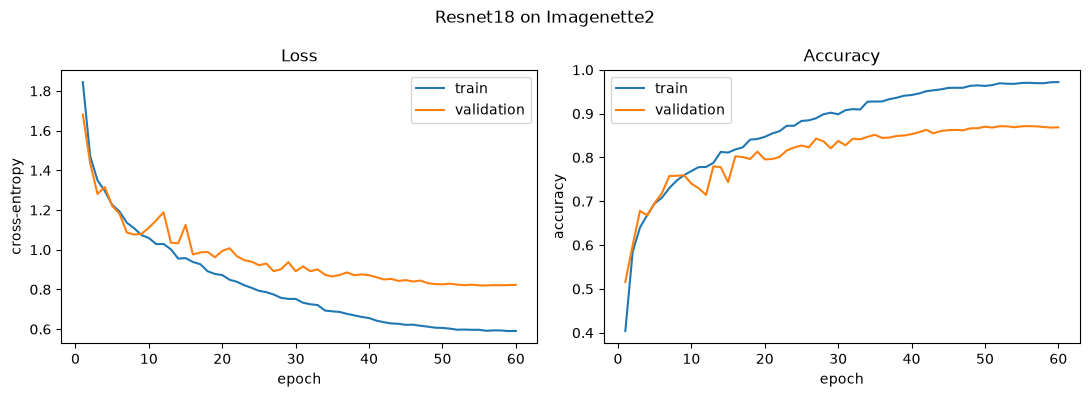

In [12]:
epochs_completed = [row["epoch"] for row in history]
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_completed, [row["loss"] for row in history], label="train")
axes[0].plot(epochs_completed, [row["val_loss"] for row in history], label="validation")
axes[0].set(xlabel="epoch", ylabel="cross-entropy", title="Loss")
axes[0].legend()
axes[1].plot(epochs_completed, [row["accuracy"] for row in history], label="train")
axes[1].plot(epochs_completed, [row["val_accuracy"] for row in history], label="validation")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
axes[1].legend()
figure.suptitle(f"{MODEL_TO_TRAIN.title()} on Imagenette2")
figure.tight_layout()

## Validation report

Imagenette2 has labeled training and validation splits but no labeled test split. The report below is useful for class-level diagnosis, but because validation loss selected the checkpoint, it is not an unbiased final test estimate.

              precision    recall  f1-score   support

   n01440764       0.92      0.93      0.93       387
   n02102040       0.92      0.95      0.94       395
   n02979186       0.82      0.89      0.86       357
   n03000684       0.77      0.77      0.77       386
   n03028079       0.90      0.90      0.90       409
   n03394916       0.88      0.86      0.87       394
   n03417042       0.86      0.89      0.87       389
   n03425413       0.86      0.78      0.82       419
   n03445777       0.90      0.88      0.89       399
   n03888257       0.89      0.87      0.88       390

    accuracy                           0.87      3925
   macro avg       0.87      0.87      0.87      3925
weighted avg       0.87      0.87      0.87      3925



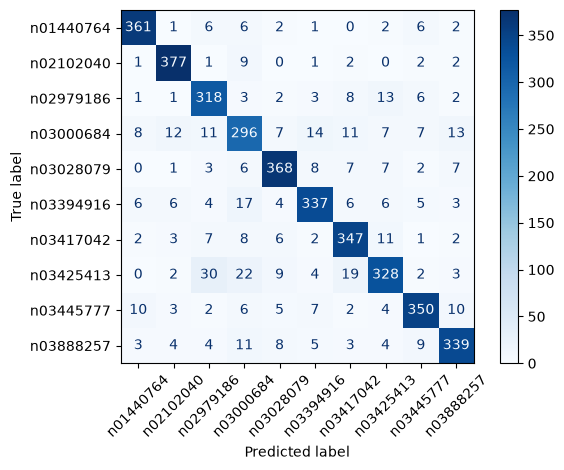

In [13]:
@torch.no_grad()
def predict_labels(model, loader):
    model.eval()
    true_labels = []
    predicted_labels = []
    for X, y in loader:
        model_output = model(X.to(device, non_blocking=True))
        logits = (
            model_output.logits
            if hasattr(model_output, "logits")
            else model_output
        )
        true_labels.extend(y.numpy())
        predicted_labels.extend(logits.argmax(dim=1).cpu().numpy())
    return np.asarray(true_labels), np.asarray(predicted_labels)

true_labels, predicted_labels = predict_labels(model, validation_loader)
print(classification_report(
    true_labels, predicted_labels, target_names=validation_dataset.classes
))
ConfusionMatrixDisplay.from_predictions(
    true_labels, predicted_labels,
    display_labels=validation_dataset.classes,
    xticks_rotation=45, cmap="Blues",
)
plt.tight_layout()

## Week 6 takeaways

- AlexNet combined deep CNNs, GPU training, ReLU, augmentation, and dropout at ImageNet scale.
- Stacked convolutions grow the receptive field and build hierarchical representations.
- Repeated $3\times3$ blocks give VGG a simple, uniform design.
- $1\times1$ convolutions mix channels and create computational bottlenecks.
- Inception concatenates parallel multi-scale branches.
- ResNet adds a residual branch to an identity or projection shortcut.
- Residual connections address optimization degradation and enable substantially deeper networks.
- DenseNet concatenates earlier representations, while ResNeXt uses grouped paths and cardinality.
- EfficientNet scales depth, width, and resolution together; ConvNeXt modernizes convolutional blocks.
- Architecture comparisons require controlled data, initialization, training budgets, and early-stopping rules.
- Interpretability methods belong to Lecture 13.